# P9 - Analyse des ventes de la librairie Lapage

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda valeur: f'{valeur:,.2f}')

import sys
sys.path.append('../src') # nom du dossier d'appartenance de data_manager.py

from data_manager import inspector # fichier data_manager.py, fonction inspector()

In [2]:
racines_candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
racine_projet = None
for candidate in racines_candidates:
    if (candidate / 'data' / 'raw').exists():
        racine_projet = candidate
        break

if racine_projet is None:
    raise FileNotFoundError("Impossible de trouver le dossier data/raw depuis ce notebook.")

dossier_donnees = racine_projet / 'data' / 'raw'

clients = pd.read_csv(dossier_donnees / 'customers.csv', sep=';')
produits = pd.read_csv(dossier_donnees / 'products.csv', sep=';')
transactions = pd.read_csv(
    dossier_donnees / 'transactions.csv',
    sep=';',
    dtype={
        'id_prod': 'string',
        'date': 'string',
        'session_id': 'string',
        'client_id': 'string',
    },
    low_memory=False,
)
nombre_transactions_brutes = len(transactions)
transactions = transactions.dropna(how='all').copy()
transactions['id_prod'] = transactions['id_prod'].astype(str)
transactions['session_id'] = transactions['session_id'].astype(str)
transactions['client_id'] = transactions['client_id'].astype(str)
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
transactions = transactions.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

clients['client_id'] = clients['client_id'].astype(str)
clients['sex'] = clients['sex'].astype(str).str.lower()
clients['birth'] = clients['birth'].astype(int)

produits['id_prod'] = produits['id_prod'].astype(str)
produits['price'] = produits['price'].astype(float)
produits['categ'] = produits['categ'].astype(int)


ventes = (
    transactions.merge(produits, on='id_prod', how='left', validate='many_to_one')
    .merge(clients, on='client_id', how='left', validate='many_to_one')
)

In [3]:
ventes = ventes.rename(columns={
        'id_prod': 'id_produit',
        'categ': 'id_categorie',
        'category_label': 'catégories',
        'price': 'prix_unitaire',
        'age_group': 'tranche_âge',
        'session_id': 'id_session',
        'age': 'âge',
        'client_id': 'id_client',
        'sex': 'genre_code',
        'sex_label': 'genre',
        'birth': 'année_naissance',
        'year': 'année',
        'month': 'mois',
        'day': 'jour',
        'year_month': 'période',
        'week': 'semaine',
        'quarter': 'trimestre',
    })

In [4]:
annee_reference = int(ventes['date'].dt.year.max())
ventes['année'] = ventes['date'].dt.year
ventes['mois'] = ventes['date'].dt.month
ventes['jour'] = ventes['date'].dt.day
ventes['période'] = ventes['date'].dt.to_period('M').dt.to_timestamp()
ventes['semaine'] = ventes['date'].dt.to_period('W-MON').dt.start_time
ventes['trimestre'] = ventes['date'].dt.to_period('Q').dt.start_time
ventes['âge'] = annee_reference - ventes['année_naissance']
ventes['tranche_âge'] = pd.cut(
    ventes['âge'],
    bins=[0, 24, 34, 44, 54, 64, 120],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    right=True,
    include_lowest=True,
)
ventes['genre'] = ventes['genre_code'].map({'f': 'Femmes', 'm': 'Hommes'}).fillna('Non renseigné')
ventes['catégories'] = ventes['id_categorie'].map({0: 'catégorie 0', 1: 'catégorie 1', 2: 'catégorie 2'})


In [5]:

nombre_transactions_supprimees = nombre_transactions_brutes - len(ventes)
part_transactions_supprimees = nombre_transactions_supprimees / nombre_transactions_brutes

vue_ensemble = pd.DataFrame(
    {
        'indicateur': [
            'Transactions brutes',
            'Transactions exploitables',
            'Transactions supprimées au nettoyage',
            'Part supprimée au nettoyage',
            'Clients uniques',
            'Produits uniques',
            'Période observée',
            'Catégories produits',
        ],
        'valeur': [
            f"{nombre_transactions_brutes:,}".replace(',', ' '),
            f"{len(ventes):,}".replace(',', ' '),
            f"{nombre_transactions_supprimees:,}".replace(',', ' '),
            f"{part_transactions_supprimees:.2%}",
            ventes['id_client'].nunique(),
            ventes['id_produit'].nunique(),
            f"{ventes['date'].min():%d/%m/%Y} -> {ventes['date'].max():%d/%m/%Y}",
            ', '.join(sorted(ventes['catégories'].dropna().unique())),
        ],
    }
)
display(vue_ensemble)


,indicateur,valeur
0,Transactions brutes,1 048 575
1,Transactions exploitables,687 534
2,Transactions supprimées au nettoyage,361 041
3,Part supprimée au nettoyage,34.43%
4,Clients uniques,8600
5,Produits uniques,3265
6,Période observée,01/03/2021 -> 28/02/2023
7,Catégories produits,"catégorie 0, catégorie 1, catégorie 2"


## 1. Perimètre et qualité des données

Le fichier `transactions.csv` contient des lignes vides. Elles sont retirées avant l'analyse, puis les ventes sont enrichies avec les informations produits et clients.


## 2. KPI globaux


Cette section répond aux besoins d'Annabelle : chiffre d'affaires, commandes, clients, panier moyen et suivi temporel.


In [6]:
nombre_commandes = ventes['id_session'].nunique()
chiffre_affaires = float(ventes['prix_unitaire'].sum())
produits_vendus = int(ventes['id_produit'].count())
nombre_clients = int(ventes['id_client'].nunique())
montant_panier_moyen = chiffre_affaires / nombre_commandes
articles_par_commande = produits_vendus / nombre_commandes

tableau_kpi = pd.DataFrame(
    {
        'KPI': [
            "Chiffre d'affaires total",
            'Nombre de commandes',
            'Nombre de clients',
            'Produits vendus',
            'Panier moyen',
            'Articles par commande',
        ],
        'Valeur': [
            f"{chiffre_affaires:,.2f} EUR",
            f"{nombre_commandes:,.0f}",
            f"{nombre_clients:,.0f}",
            f"{produits_vendus:,.0f}",
            f"{montant_panier_moyen:,.2f} EUR",
            f"{articles_par_commande:,.2f}",
        ],
    }
)
display(tableau_kpi)


,KPI,Valeur
0,Chiffre d'affaires total,"12,027,663.10 EUR"
1,Nombre de commandes,"345,505"
2,Nombre de clients,"8,600"
3,Produits vendus,"687,534"
4,Panier moyen,34.81 EUR
5,Articles par commande,1.99


## 3. Analyse par catégorie et par référence

Cette partie met en avant le poids des catégories, les meilleures références et les moins performantes.


In [7]:
ca_mensuel = (
    ventes.groupby('période', as_index=False)
    .agg(
        chiffre_affaires=('prix_unitaire', 'sum'),
        nombre_commandes=('id_session', 'nunique'),
        nombre_clients=('id_client', 'nunique'),
        produits_vendus=('id_produit', 'count'),
    )
    .sort_values('période')
)

ca_mensuel['moyenne_mobile_3_mois'] = ca_mensuel['chiffre_affaires'].rolling(window=3, min_periods=1).mean()

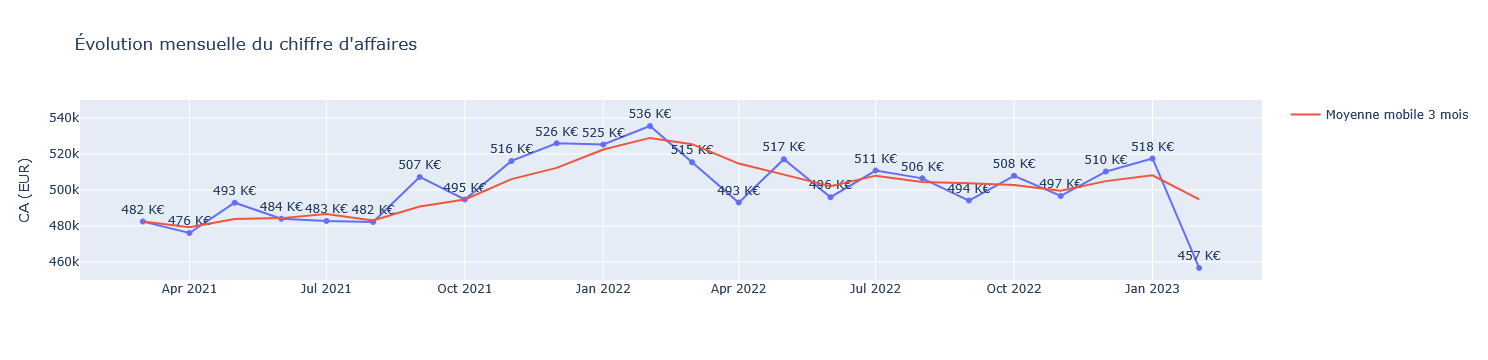

In [8]:

ca_mensuel['chiffre_affaires_label'] = ca_mensuel['chiffre_affaires'].map(
    lambda x: f"{round(x / 1000):.0f} K€"
)
figure_ca = px.line(
    ca_mensuel,
    x='période',
    y='chiffre_affaires',
    markers=True,
    text='chiffre_affaires_label',
    title="Évolution mensuelle du chiffre d'affaires"
)

figure_ca.update_traces(
    textposition='top center'
)

figure_ca.add_scatter(
    x=ca_mensuel['période'],
    y=ca_mensuel['moyenne_mobile_3_mois'],
    mode='lines',
    name='Moyenne mobile 3 mois'
)

figure_ca.update_layout(
    xaxis_title='',
    yaxis_title='CA (EUR)',
    yaxis_range=[450000, 550000]
)

figure_ca.show()

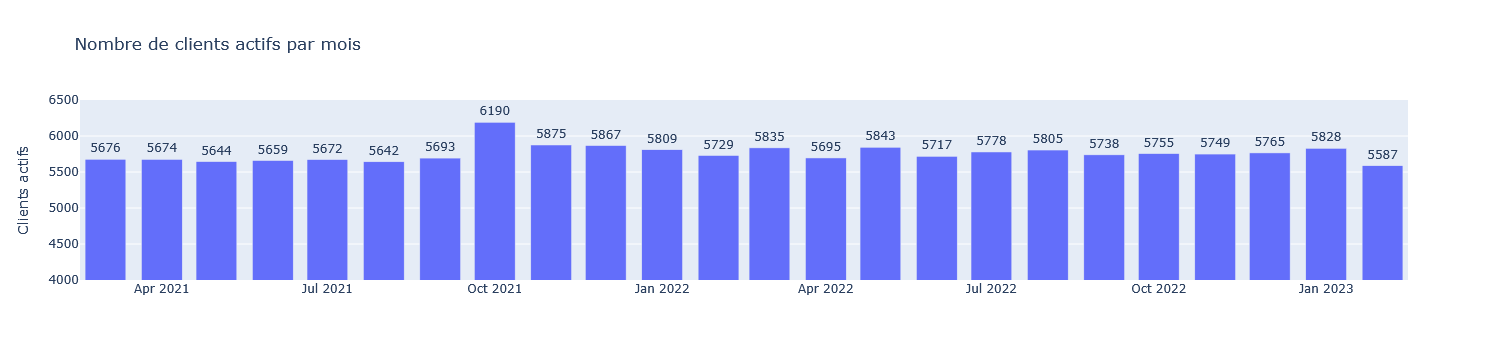

In [9]:
figure_clients = px.bar(
    ca_mensuel,
    x='période',
    y='nombre_clients',
    text='nombre_clients',
    title='Nombre de clients actifs par mois'
)

figure_clients.update_traces(
    textposition='outside'
)

figure_clients.update_layout(
    xaxis_title='',
    yaxis_title='Clients actifs',
    yaxis_range=[4000, 6500]
)

figure_clients.show()

In [10]:
#Vérification pour savoir si le nombe de client à augmenté suite à l'ajout d'une nouvelle référence

premiere_vente_par_produit = (
    ventes.groupby('id_produit', as_index=False)
    .agg(premiere_vente=('date', 'min'))
)

premiere_vente_par_produit['premier_mois_vente'] = (
    premiere_vente_par_produit['premiere_vente'].dt.to_period('M').dt.to_timestamp()
)

ventes_octobre_2021 = ventes[
    ventes['période'] == pd.Timestamp('2021-10-01')
].copy()

ventes_octobre_2021 = ventes_octobre_2021.merge(
    premiere_vente_par_produit[['id_produit', 'premier_mois_vente']],
    on='id_produit',
    how='left'
)

nouvelles_references_octobre = (
    ventes_octobre_2021[
        ventes_octobre_2021['premier_mois_vente'] == pd.Timestamp('2021-10-01')
    ]
    .groupby('id_produit', as_index=False)
    .agg(
        catégories=('catégories', 'first'),
        chiffre_affaires_octobre=('prix_unitaire', 'sum'),
        ventes_octobre=('id_produit', 'count')
    )
    .sort_values('chiffre_affaires_octobre', ascending=False)
)

ca_total_octobre = ventes_octobre_2021['prix_unitaire'].sum()
ca_nouvelles_references = nouvelles_references_octobre['chiffre_affaires_octobre'].sum()

part_ca_nouvelles_references = ca_nouvelles_references / ca_total_octobre

print(f"Nombre de nouvelles références en octobre 2021 : {len(nouvelles_references_octobre)}")
print(f"CA généré par ces nouvelles références : {ca_nouvelles_references:.2f} €")
print(f"Part du CA d'octobre portée par ces nouvelles références : {part_ca_nouvelles_references:.2%}")

display(nouvelles_references_octobre)

Nombre de nouvelles références en octobre 2021 : 17
CA généré par ces nouvelles références : 648.05 €
Part du CA d'octobre portée par ces nouvelles références : 0.13%


,id_produit,catégories,chiffre_affaires_octobre,ventes_octobre
16,2_78,catégorie 2,167.49,1
14,2_131,catégorie 2,127.99,1
15,2_68,catégorie 2,88.29,1
7,0_247,catégorie 0,55.98,2
1,0_1331,catégorie 0,29.99,1
10,0_808,catégorie 0,27.85,1
5,0_1592,catégorie 0,25.23,1
3,0_1484,catégorie 0,25.23,1
0,0_1237,catégorie 0,24.99,1
13,0_945,catégorie 0,22.99,1


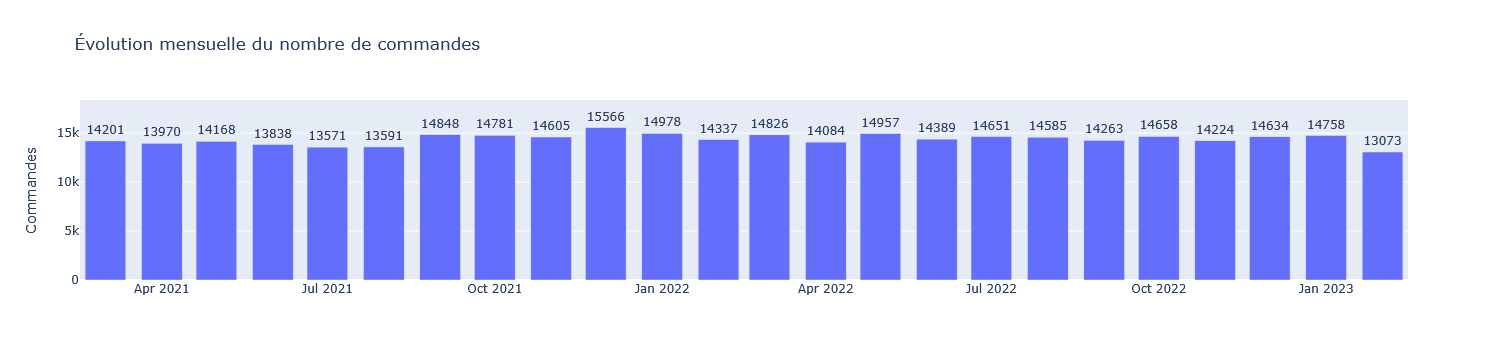

In [11]:
figure_commandes = px.bar(ca_mensuel, x='période', y='nombre_commandes', title='Évolution mensuelle du nombre de commandes', text='nombre_commandes')
figure_commandes.update_layout(xaxis_title='', yaxis_title='Commandes')
figure_commandes.update_traces(
    texttemplate='%{text}',
    textposition='outside'
)
figure_commandes.show()

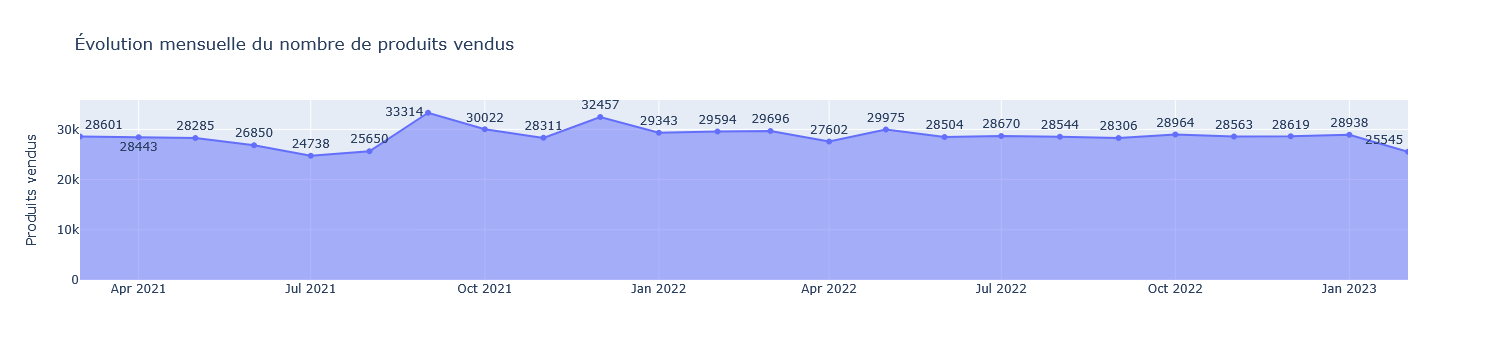

In [12]:
figure_produits_vendus = px.area(ca_mensuel, x='période', y='produits_vendus', title='Évolution mensuelle du nombre de produits vendus', text='produits_vendus')
figure_produits_vendus.update_layout(xaxis_title='', yaxis_title='Produits vendus')
figure_produits_vendus.update_traces(
    texttemplate='%{text}',
    textposition=["top right", "bottom center", "top center", "top center","top center","top center","middle left","top center","top center","top center","top center","top center","top center","top center","top center","top center","top center","top center","top center","top center","top center","top center","top center", "top left"]
)
figure_produits_vendus.show()

In [13]:

ca_journalier = (
    ventes.groupby('date', as_index=False)
    .agg(
        chiffre_affaires=('prix_unitaire', 'sum'),
        nombre_commandes=('id_session', 'nunique'),
        nombre_clients=('id_client', 'nunique'),
        produits_vendus=('id_produit', 'count'),
    )
    .sort_values('date')
)

ca_journalier = ca_journalier.set_index('date')

ca_journalier['moyenne_mobile_2_semaines'] = (
    ca_journalier['chiffre_affaires']
    .rolling('14D')
    .mean()
)

ca_journalier = ca_journalier.reset_index()

In [14]:
ca_journalier = (
    ventes.groupby(ventes['date'].dt.floor('D'), as_index=False)
    .agg(
        chiffre_affaires=('prix_unitaire', 'sum'),
        nombre_commandes=('id_session', 'nunique'),
        nombre_clients=('id_client', 'nunique'),
        produits_vendus=('id_produit', 'count'),
    )
    .rename(columns={'date': 'jour'})
    .sort_values('jour')
)

ca_journalier['moyenne_mobile_2_semaines'] = (
    ca_journalier['chiffre_affaires']
    .rolling(window=14, min_periods=1)
    .mean()
)

ca_mensuel = (
    ventes.groupby('période', as_index=False)
    .agg(
        chiffre_affaires=('prix_unitaire', 'sum'),
        nombre_commandes=('id_session', 'nunique'),
        nombre_clients=('id_client', 'nunique'),
        produits_vendus=('id_produit', 'count'),
    )
    .sort_values('période')
)

ca_mensuel['moyenne_mobile_3_mois'] = (
    ca_mensuel['chiffre_affaires']
    .rolling(window=3, min_periods=1)
    .mean()
)

ca_journalier = (
    ventes.groupby(ventes['date'].dt.floor('D'), as_index=False)
    .agg(
        chiffre_affaires=('prix_unitaire', 'sum'),
        nombre_commandes=('id_session', 'nunique'),
        nombre_clients=('id_client', 'nunique'),
        produits_vendus=('id_produit', 'count'),
    )
    .rename(columns={'date': 'jour'})
    .sort_values('jour')
)

ca_journalier['moyenne_mobile_2_semaines'] = (
    ca_journalier['chiffre_affaires']
    .rolling(window=14, min_periods=1)
    .mean()
)
ca_journalier['moyenne_mobile_7_jours'] = (
    ca_journalier['chiffre_affaires']
    .rolling(window=7, min_periods=1)
    .mean()
)

ca_journalier['moyenne_mobile_1_mois'] = (
    ca_journalier['chiffre_affaires']
    .rolling(window=30, min_periods=1)
    .mean()
)

ca_journalier['moyenne_mobile_2_mois'] = (
    ca_journalier['chiffre_affaires']
    .rolling(window=60, min_periods=1)
    .mean()
)

ca_journalier['moyenne_mobile_3_mois'] = (
    ca_journalier['chiffre_affaires']
    .rolling(window=90, min_periods=1)
    .mean()
)

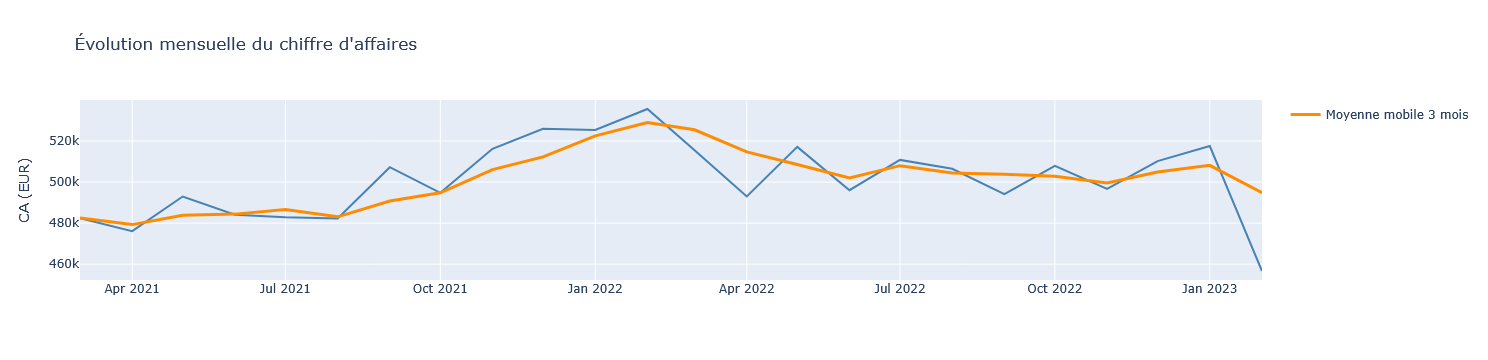

In [15]:
figure_ca_mensuel = px.line(
    ca_mensuel,
    x='période',
    y='chiffre_affaires',
    title="Évolution mensuelle du chiffre d'affaires"
)
figure_ca_mensuel.update_traces(
    name='CA mensuel',
    line=dict(color='steelblue', width=2)
)
figure_ca_mensuel.add_scatter(
    x=ca_mensuel['période'],
    y=ca_mensuel['moyenne_mobile_3_mois'],
    mode='lines',
    name='Moyenne mobile 3 mois',
    line=dict(color='darkorange', width=3)
)
figure_ca_mensuel.update_layout(xaxis_title='', yaxis_title='CA (EUR)')
figure_ca_mensuel.show()

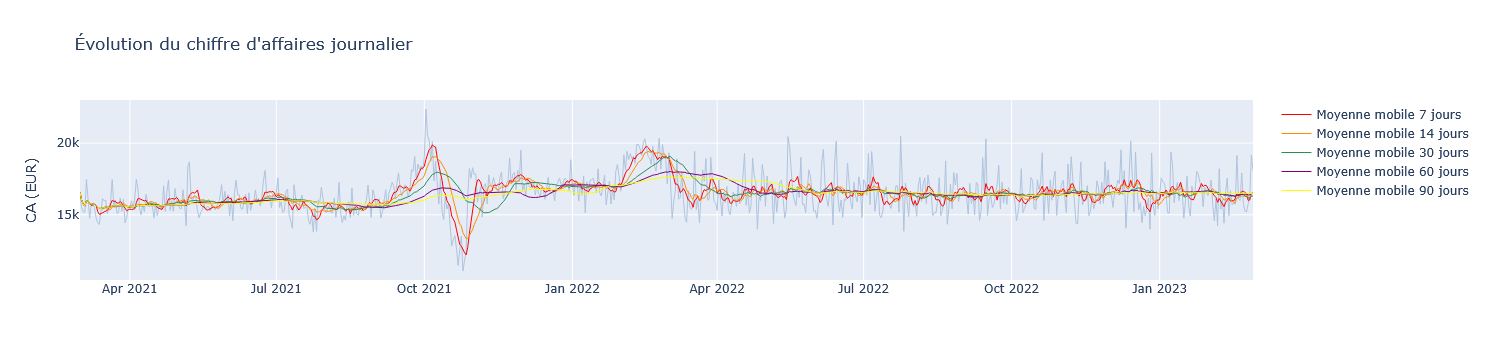

In [16]:
figure_ca_journalier = px.line(
    ca_journalier,
    x='jour',
    y='chiffre_affaires',
    title="Évolution du chiffre d'affaires journalier"
)

figure_ca_journalier.update_traces(
    name='CA journalier',
    line=dict(color='lightsteelblue', width=1)
)

figure_ca_journalier.add_scatter(
    x=ca_journalier['jour'],
    y=ca_journalier['moyenne_mobile_7_jours'],
    mode='lines',
    name='Moyenne mobile 7 jours',
    line=dict(color='red', width=1)
)
figure_ca_journalier.add_scatter(
    x=ca_journalier['jour'],
    y=ca_journalier['moyenne_mobile_2_semaines'],
    mode='lines',
    name='Moyenne mobile 14 jours',
    line=dict(color='darkorange', width=1)
)

figure_ca_journalier.add_scatter(
    x=ca_journalier['jour'],
    y=ca_journalier['moyenne_mobile_1_mois'],
    mode='lines',
    name='Moyenne mobile 30 jours',
    line=dict(color='seagreen', width=1)
)

figure_ca_journalier.add_scatter(
    x=ca_journalier['jour'],
    y=ca_journalier['moyenne_mobile_2_mois'],
    mode='lines',
    name='Moyenne mobile 60 jours',
    line=dict(color='purple', width=1)
)

figure_ca_journalier.add_scatter(
    x=ca_journalier['jour'],
    y=ca_journalier['moyenne_mobile_3_mois'],
    mode='lines',
    name='Moyenne mobile 90 jours',
    line=dict(color='yellow', width=1)
)

figure_ca_journalier.update_layout(
    xaxis_title='',
    yaxis_title='CA (EUR)',
    hovermode='x unified'
)

figure_ca_journalier.show()

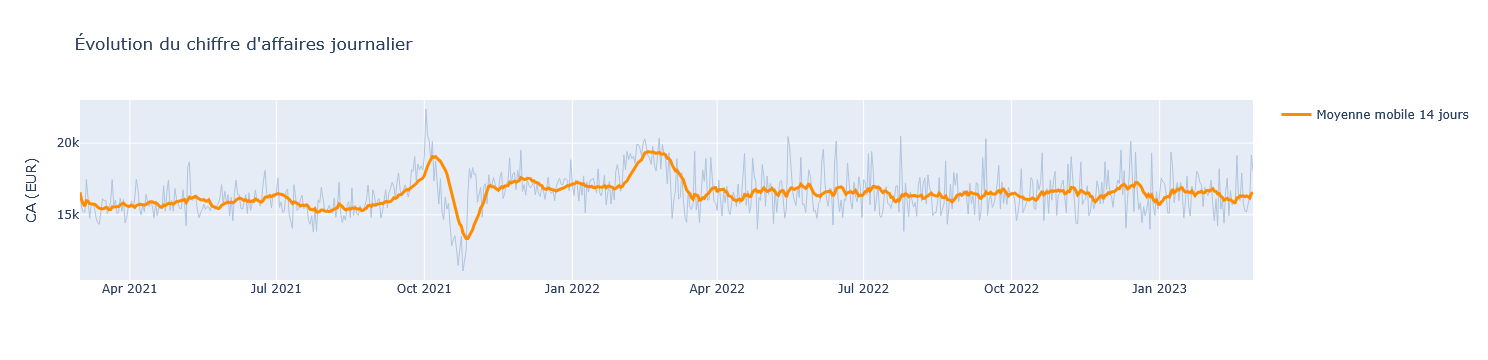

In [17]:
figure_ca_journalier = px.line(
    ca_journalier,
    x='jour',
    y='chiffre_affaires',
    title="Évolution du chiffre d'affaires journalier"
)

figure_ca_journalier.update_traces(
    name='CA journalier',
    line=dict(color='lightsteelblue', width=1)
)


figure_ca_journalier.add_scatter(
    x=ca_journalier['jour'],
    y=ca_journalier['moyenne_mobile_2_semaines'],
    mode='lines',
    name='Moyenne mobile 14 jours',
    line=dict(color='darkorange', width=3)
)

figure_ca_journalier.update_layout(
    xaxis_title='',
    yaxis_title='CA (EUR)',
    hovermode='x unified'
)

figure_ca_journalier.show()

,id_categorie,catégories,chiffre_affaires,produits_vendus,part_chiffre_affaires,part_produits_vendus
0,0,catégorie 0,"4 419 730,97","415 459,00",36.7%,60.4%
1,1,catégorie 1,"4 827 657,11","235 592,00",40.1%,34.3%
2,2,catégorie 2,"2 780 275,02","36 483,00",23.1%,5.3%


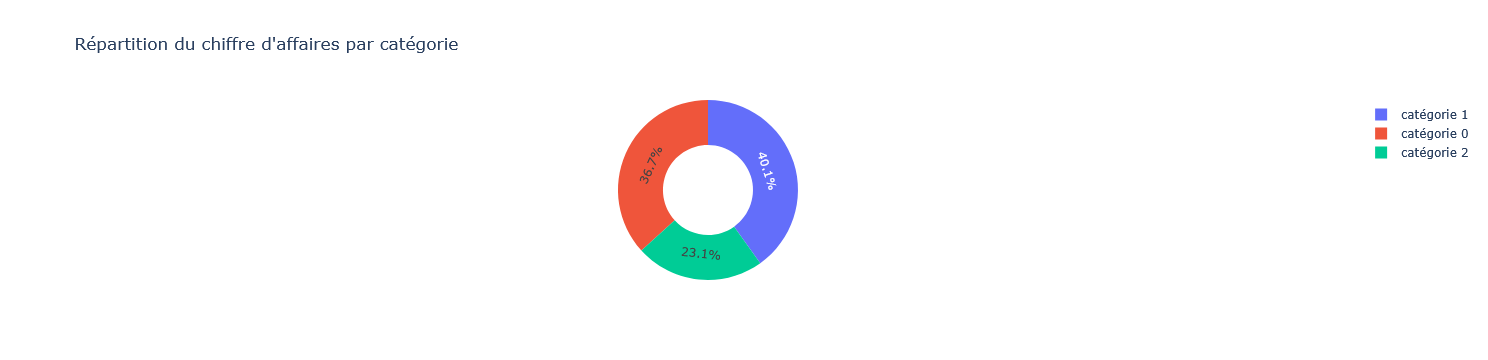

In [18]:
mix_categories = (
    ventes.groupby(['id_categorie', 'catégories'], as_index=False)
    .agg(chiffre_affaires=('prix_unitaire', 'sum'), produits_vendus=('id_produit', 'count'))
    .sort_values('catégories', ascending=True)
)
mix_categories['part_chiffre_affaires'] = mix_categories['chiffre_affaires'] / mix_categories['chiffre_affaires'].sum()
mix_categories['part_produits_vendus'] = mix_categories['produits_vendus'] / mix_categories['produits_vendus'].sum()

mix_categories['part_chiffre_affaires'] = (
    mix_categories['part_chiffre_affaires']
    .map(lambda x: f"{x:.1%}")
)

mix_categories['part_produits_vendus'] = (
    mix_categories['part_produits_vendus']
    .map(lambda x: f"{x:.1%}")
)

mix_categories_affichage = mix_categories.copy()

mix_categories_affichage['chiffre_affaires'] = mix_categories_affichage['chiffre_affaires'].map(
    lambda x: f"{x:,.2f}".replace(",", " ").replace(".", ",")
)
mix_categories_affichage['produits_vendus'] = mix_categories_affichage['produits_vendus'].map(
    lambda x: f"{x:,.2f}".replace(",", " ").replace(".", ",")
)
display(mix_categories_affichage)

figure_categories = px.pie(mix_categories, names='catégories', values='chiffre_affaires', hole=0.5, title="Répartition du chiffre d'affaires par catégorie")
figure_categories.show()

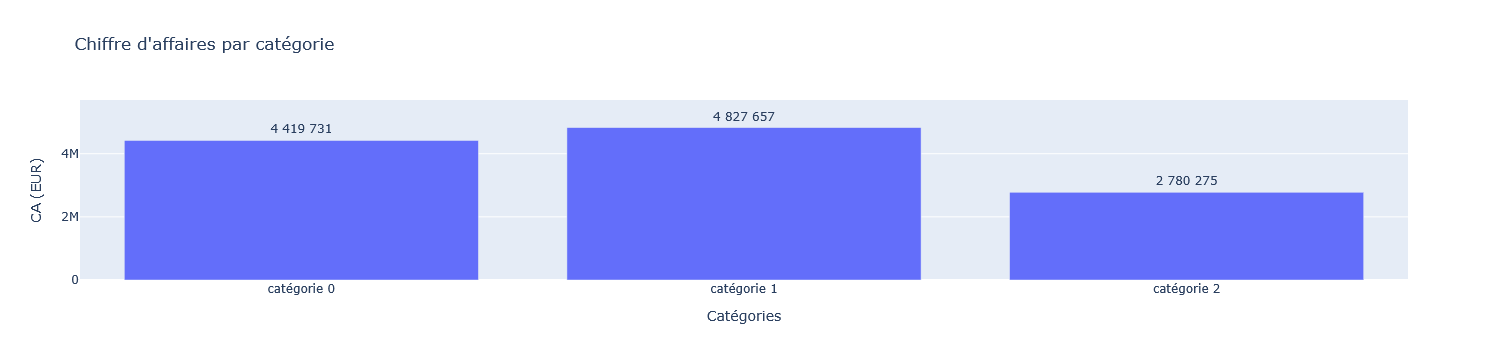

In [19]:
figure_ca_categories = px.bar(mix_categories, x='catégories', y='chiffre_affaires', text='chiffre_affaires', title="Chiffre d'affaires par catégorie")

figure_ca_categories.update_layout(xaxis_title='Catégories', yaxis_title='CA (EUR)')

figure_ca_categories.update_traces(
    text=mix_categories['chiffre_affaires'].map(lambda x: f"{x:,.0f}".replace(",", " ")),
    textposition='outside'
)

figure_ca_categories.show()

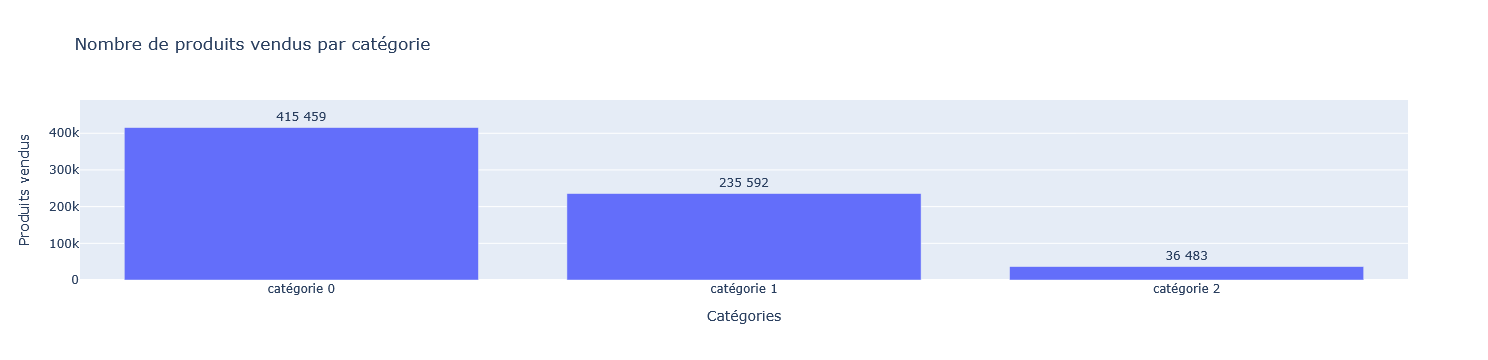

In [20]:
figure_volumes_categories = px.bar(
    mix_categories,
    x='catégories',
    y='produits_vendus',
    title='Nombre de produits vendus par catégorie'
)

figure_volumes_categories.update_traces(
    text=mix_categories['produits_vendus'].map(lambda x: f"{x:,.0f}".replace(",", " ")),
    textposition='outside'
)

figure_volumes_categories.update_layout(
    xaxis_title='Catégories',
    yaxis_title='Produits vendus'
)

figure_volumes_categories.show()

,id_produit,id_categorie,catégories,prix_unitaire,chiffre_affaires,produits_vendus
3096,2_159,2,catégorie 2,145.99,"94,893.50",650
3070,2_135,2,catégorie 2,68.99,"69,334.95",1005
3045,2_112,2,catégorie 2,67.57,"65,407.76",968
3034,2_102,2,catégorie 2,59.14,"60,736.78",1027
3152,2_209,2,catégorie 2,69.99,"56,971.86",814
2619,1_395,1,catégorie 1,28.99,"56,617.47",1953
2591,1_369,1,catégorie 1,23.99,"56,136.60",2340
3043,2_110,2,catégorie 2,62.25,"53,846.25",865
2607,1_383,1,catégorie 1,28.99,"53,834.43",1857
2641,1_414,1,catégorie 1,23.83,"53,522.18",2246


,id_produit,id_categorie,catégories,prix_unitaire,chiffre_affaires,produits_vendus
595,0_1539,0,catégorie 0,0.99,0.99,1
313,0_1284,0,catégorie 0,1.38,1.38,1
719,0_1653,0,catégorie 0,0.99,1.98,2
2079,0_807,0,catégorie 0,1.99,1.99,1
665,0_1601,0,catégorie 0,1.99,1.99,1
1784,0_541,0,catégorie 0,1.99,1.99,1
802,0_1728,0,catégorie 0,2.27,2.27,1
549,0_1498,0,catégorie 0,2.48,2.48,1
2179,0_898,0,catégorie 0,1.27,2.54,2
925,0_1840,0,catégorie 0,1.28,2.56,2


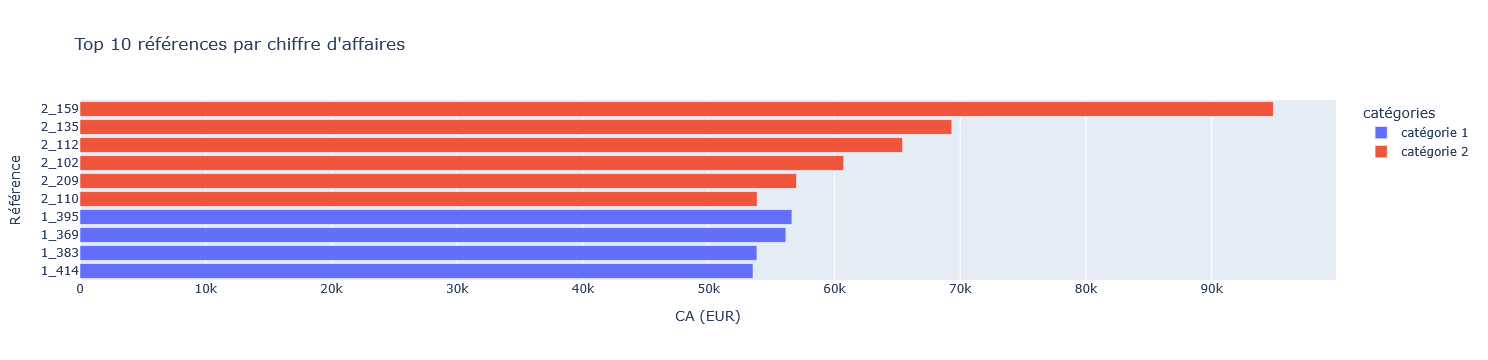

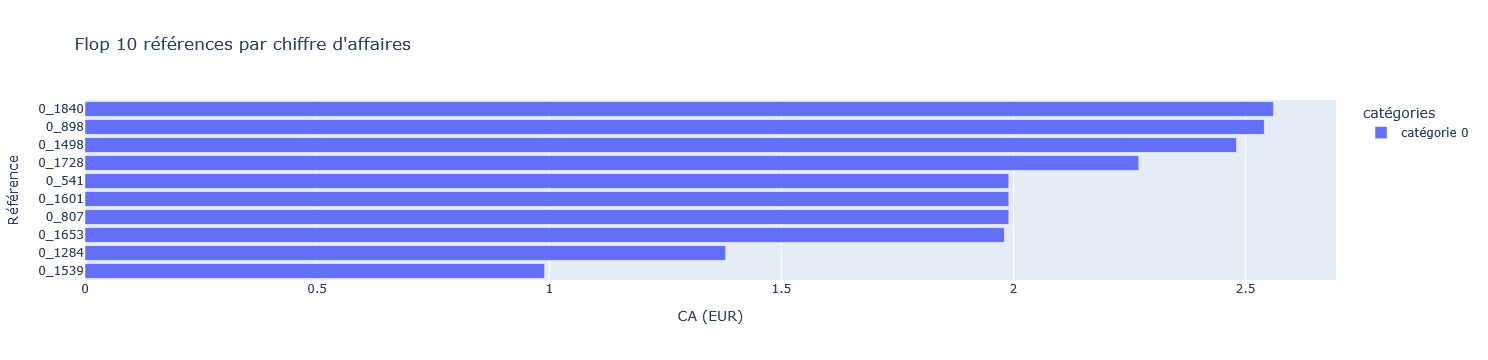

In [21]:
performance_produits = (
    ventes.groupby(['id_produit', 'id_categorie', 'catégories', 'prix_unitaire'], as_index=False)
    .agg(chiffre_affaires=('prix_unitaire', 'sum'), produits_vendus=('id_produit', 'count'))
    .sort_values(['chiffre_affaires', 'produits_vendus'], ascending=[False, False])
)

meilleurs_produits = performance_produits.head(10)
produits_moins_performants = performance_produits.tail(10).sort_values('chiffre_affaires', ascending=True)

meilleurs_produits_affichage = meilleurs_produits.rename(
    columns={
    }
)
produits_moins_performants_affichage = produits_moins_performants.rename(
    columns={
    }
)
display(meilleurs_produits_affichage)
display(produits_moins_performants_affichage)

figure_meilleurs_produits = px.bar(meilleurs_produits.sort_values('chiffre_affaires'), x='chiffre_affaires', y='id_produit', orientation='h', color='catégories', title="Top 10 références par chiffre d'affaires")
figure_meilleurs_produits.update_layout(xaxis_title='CA (EUR)', yaxis_title='Référence')
figure_meilleurs_produits.show()

figure_produits_moins_performants = px.bar(produits_moins_performants, x='chiffre_affaires', y='id_produit', orientation='h', color='catégories', title="Flop 10 références par chiffre d'affaires")
figure_produits_moins_performants.update_layout(xaxis_title='CA (EUR)', yaxis_title='Référence')
figure_produits_moins_performants.show()


## 4. Profils clients et concentration du chiffre d'affaires

Cette section prépare la lecture client : concentration des revenus, clients atypiques et réponse à la partie BtoB du brief.


In [22]:
ventes.head()

,id_produit,date,id_session,id_client,prix_unitaire,id_categorie,genre_code,année_naissance,année,mois,jour,période,semaine,trimestre,âge,tranche_âge,genre,catégories
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,2021,3,1,2021-03-01,2021-02-23,2021-01-01,56,55-64,Femmes,catégorie 0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,2021,3,1,2021-03-01,2021-02-23,2021-01-01,63,55-64,Hommes,catégorie 0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,2021,3,1,2021-03-01,2021-02-23,2021-01-01,35,35-44,Hommes,catégorie 0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,2021,3,1,2021-03-01,2021-02-23,2021-01-01,34,25-34,Femmes,catégorie 0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,2021,3,1,2021-03-01,2021-02-23,2021-01-01,67,65+,Femmes,catégorie 0


In [23]:
metriques_sessions = (
    ventes.groupby(['id_client', 'id_session'], as_index=False)
    .agg(panier=('prix_unitaire', 'sum'), taille_panier=('id_produit', 'count'), date=('date', 'min'))
)

metriques_clients = (
    ventes.groupby(['id_client', 'genre_code', 'genre', 'année_naissance', 'âge', 'tranche_âge'], as_index=False, observed=True)
    .agg(chiffre_affaires=('prix_unitaire', 'sum'), produits_vendus=('id_produit', 'count'))
    .merge(
        metriques_sessions.groupby('id_client', as_index=False).agg(
            nombre_commandes=('id_session', 'nunique'),
            montant_panier_moyen=('panier', 'mean'),
            taille_panier_moyen=('taille_panier', 'mean'),
            premier_achat=('date', 'min'),
            dernier_achat=('date', 'max'),
        ),
        on='id_client',
        how='left',
    )
)

metriques_clients['commandes_par_mois'] = metriques_clients['nombre_commandes'] / ((metriques_clients['dernier_achat'] - metriques_clients['premier_achat']).dt.days.clip(lower=1) / 30.4375)
metriques_clients['part_chiffre_affaires'] = metriques_clients['chiffre_affaires'] / metriques_clients['chiffre_affaires'].sum()

display(metriques_clients.head(10))


,id_client,genre_code,genre,année_naissance,âge,tranche_âge,chiffre_affaires,produits_vendus,nombre_commandes,montant_panier_moyen,taille_panier_moyen,premier_achat,dernier_achat,commandes_par_mois,part_chiffre_affaires
0,c_1,m,Hommes,1955,68,65+,629.02,43,34,18.50,1.26,2021-06-11 21:02:39.382765,2023-01-15 20:40:00.586010,1.78,0.00
1,c_10,m,Hommes,1956,67,65+,"1,353.60",58,34,39.81,1.71,2021-03-21 02:50:16.551727,2023-01-27 03:34:47.280771,1.53,0.00
2,c_100,m,Hommes,1992,31,25-34,254.85,8,5,50.97,1.60,2021-04-20 05:26:43.133053,2022-09-20 05:26:43.133053,0.29,0.00
3,c_1000,f,Femmes,1966,57,55-64,"2,291.88",126,94,24.38,1.34,2021-03-13 13:34:14.618755,2023-01-24 13:34:23.415697,4.20,0.00
4,c_1001,m,Hommes,1982,41,35-44,"1,823.85",103,47,38.81,2.19,2021-03-07 13:01:15.964197,2023-02-23 22:46:16.844888,1.99,0.00
5,c_1002,f,Femmes,1982,41,35-44,436.54,37,20,21.83,1.85,2021-04-02 22:33:56.033965,2023-02-16 03:35:44.038986,0.89,0.00
6,c_1003,m,Hommes,1982,41,35-44,"1,230.83",106,45,27.35,2.36,2021-03-07 23:11:21.412403,2023-02-17 00:57:27.071584,1.93,0.00
7,c_1004,m,Hommes,1973,50,45-54,"1,077.83",68,33,32.66,2.06,2021-03-02 21:48:09.056146,2023-02-23 01:48:10.615556,1.39,0.00
8,c_1005,f,Femmes,1941,82,65+,844.93,59,23,36.74,2.57,2021-03-07 01:29:23.941625,2023-02-21 02:53:55.907088,0.98,0.00
9,c_1006,m,Hommes,1979,44,35-44,"4,029.97",299,129,31.24,2.32,2021-03-09 19:16:13.573155,2023-02-18 22:20:23.542254,5.52,0.00


In [24]:
q1_ca = metriques_clients['chiffre_affaires'].quantile(0.25)
q3_ca = metriques_clients['chiffre_affaires'].quantile(0.75)

q1_cmd = metriques_clients['nombre_commandes'].quantile(0.25)
q3_cmd = metriques_clients['nombre_commandes'].quantile(0.75)
seuil_ca = q3_ca + 3 * (q3_ca - q1_ca)
seuil_cmd = q3_cmd + 3 * (q3_cmd - q1_cmd)

metriques_clients_b2b = metriques_clients.copy()
metriques_clients_b2b['segment'] = 'Client standard'

metriques_clients_b2b.loc[
    (metriques_clients_b2b['chiffre_affaires'] >= seuil_ca) &
    (metriques_clients_b2b['nombre_commandes'] >= seuil_cmd),
    'segment'
] = 'B2B probable'

figure_b2b = px.scatter(
    metriques_clients_b2b,
    x='nombre_commandes',
    y='chiffre_affaires',
    color='segment',
    hover_data=['id_client', 'montant_panier_moyen', 'taille_panier_moyen'],
    title="Identification des clients atypiques / B2B probables"
)

figure_b2b.update_layout(
    xaxis_title='Nombre de commandes',
    yaxis_title="Chiffre d'affaires client"
)

figure_b2b.show()

In [25]:
candidats_b2b = metriques_clients.loc[
    (metriques_clients['chiffre_affaires'] >= seuil_ca) & (metriques_clients['nombre_commandes'] >= seuil_cmd)
].copy()
candidats_b2b['segment'] = 'B2B probable'
display(candidats_b2b)

,id_client,genre_code,genre,année_naissance,âge,tranche_âge,chiffre_affaires,produits_vendus,nombre_commandes,montant_panier_moyen,taille_panier_moyen,premier_achat,dernier_achat,commandes_par_mois,part_chiffre_affaires,segment
677,c_1609,m,Hommes,1980,43,35-44,"326,039.89",25586,10997,29.65,2.33,2021-03-01 00:07:04.371179,2023-02-28 22:29:54.677919,459.15,0.03,B2B probable
2724,c_3454,m,Hommes,1969,54,45-54,"114,110.57",6793,5571,20.48,1.22,2021-03-01 01:08:49.803921,2023-02-28 23:16:12.006088,232.60,0.01,B2B probable
4388,c_4958,m,Hommes,1999,24,18-24,"290,227.03",5222,3851,75.36,1.36,2021-03-01 04:54:48.643575,2023-02-28 21:45:26.670082,160.79,0.02,B2B probable
6337,c_6714,f,Femmes,1968,55,55-64,"153,918.60",9199,2620,58.75,3.51,2021-03-01 06:44:06.269773,2023-02-28 22:21:45.543853,109.39,0.01,B2B probable


In [26]:

repartition_ca_sexe = metriques_clients.groupby('genre', as_index=False).agg(chiffre_affaires=('chiffre_affaires', 'sum'), nombre_clients=('id_client', 'count'))
display(repartition_ca_sexe)

,genre,chiffre_affaires,nombre_clients
0,Femmes,"5,950,843.68",4479
1,Hommes,"6,076,819.42",4121


In [27]:
figure_ca_sexe = px.bar(repartition_ca_sexe, x='genre', y='chiffre_affaires', text='nombre_clients', title="Chiffre d'affaires par sexe")
figure_ca_sexe.update_layout(xaxis_title='', yaxis_title='CA (EUR)')
figure_ca_sexe.show()

In [28]:
courbe_lorenz = metriques_clients.sort_values('chiffre_affaires').reset_index(drop=True)
courbe_lorenz['part_population'] = (courbe_lorenz.index + 1) / len(courbe_lorenz)
courbe_lorenz['part_chiffre_affaires_cumulee'] = courbe_lorenz['chiffre_affaires'].cumsum() / courbe_lorenz['chiffre_affaires'].sum()

courbe_lorenz['part_population'] = (
    courbe_lorenz['part_population']
    .map(lambda x: f"{x:.1%}")
)

courbe_lorenz['part_chiffre_affaires_cumulee'] = (
    courbe_lorenz['part_chiffre_affaires_cumulee']
    .map(lambda x: f"{x:.1%}")
)



courbe_lorenz = pd.concat(
    [pd.DataFrame({'part_population': [0.0], 'part_chiffre_affaires_cumulee': [0.0]}), courbe_lorenz[['part_population', 'part_chiffre_affaires_cumulee']]],
    ignore_index=True,
)

figure_lorenz = go.Figure()
figure_lorenz.add_trace(go.Scatter(x=courbe_lorenz['part_population'], y=courbe_lorenz['part_chiffre_affaires_cumulee'], mode='lines', name='Courbe de Lorenz'))
figure_lorenz.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Égalité parfaite', line={'dash': 'dash'}))
figure_lorenz.update_layout(title="Concentration du chiffre d'affaires", xaxis_title='Part cumulée des clients', yaxis_title='Part cumulée du CA')
figure_lorenz.show()


## 5. Corrélations demandées par Julie

- lien entre le genre et les catégories achetées ;
- lien entre l'âge et le montant total des achats ;
- lien entre l'âge et la fréquence d'achat ;
- lien entre l'âge et la taille du panier moyen ;
- lien entre l'âge et la catégorie des livres achetés.


In [29]:
repartition_genre_categorie = (
    ventes.groupby(['genre', 'catégories'], as_index=False)
    .agg(chiffre_affaires=('prix_unitaire', 'sum'), produits_vendus=('id_produit', 'count'))
    .sort_values(['genre', 'chiffre_affaires'], ascending=[True, False])
)
repartition_genre_categorie['part_chiffre_affaires'] = repartition_genre_categorie['chiffre_affaires'] / repartition_genre_categorie.groupby('genre')['chiffre_affaires'].transform('sum')





repartition_genre_categorie_affichage = repartition_genre_categorie.rename(
    columns={
    }
)

repartition_genre_categorie_affichage['part_chiffre_affaires'] = (
    repartition_genre_categorie_affichage['part_chiffre_affaires']
    .map(lambda x: f"{x:.2%}")
)


display(repartition_genre_categorie_affichage)

,genre,catégories,chiffre_affaires,produits_vendus,part_chiffre_affaires
1,Femmes,catégorie 1,"2,449,577.57",119307,41.16%
0,Femmes,catégorie 0,"2,190,013.07",206103,36.80%
2,Femmes,catégorie 2,"1,311,253.04",17283,22.03%
4,Hommes,catégorie 1,"2,378,079.54",116285,39.13%
3,Hommes,catégorie 0,"2,229,717.90",209356,36.69%
5,Hommes,catégorie 2,"1,469,021.98",19200,24.17%


In [30]:
repartition_femmes = repartition_genre_categorie[
    repartition_genre_categorie['genre'] == 'Femmes'
]

figure_femmes = px.pie(
    repartition_femmes,
    names='catégories',
    values='chiffre_affaires',
    hole=0.4,
    title="Répartition du chiffre d'affaires par catégorie - Femmes"
)

figure_femmes.update_traces(
    textinfo='percent+label'
)

figure_femmes.show()

In [31]:
repartition_hommes = repartition_genre_categorie[
    repartition_genre_categorie['genre'] == 'Hommes'
]

figure_hommes = px.pie(
    repartition_hommes,
    names='catégories',
    values='chiffre_affaires',
    hole=0.4,
    title="Répartition du chiffre d'affaires par catégorie - Hommes"
)

figure_hommes.update_traces(
    textinfo='percent+label'
)

figure_hommes.show()

In [32]:
repartition_genre_categorie['part_chiffre_affaires_label'] = (
    repartition_genre_categorie['part_chiffre_affaires']
    .map(lambda x: f"{x:.2%}")
)

figure_genre_categorie = px.bar(
    repartition_genre_categorie,
    x='genre',
    y='part_chiffre_affaires',
    color='catégories',
    barmode='stack',
    text='part_chiffre_affaires_label',
    title='Lien entre genre et catégories achetées'
)

figure_genre_categorie.update_traces(
    textposition='inside'
)

figure_genre_categorie.update_layout(
    xaxis_title='',
    yaxis_title='Part du CA',
    yaxis_tickformat='.0%'
)

figure_genre_categorie.show()

In [33]:
repartition_age_categorie = (
    ventes.groupby(['tranche_âge', 'catégories'], as_index=False, observed=False)
    .agg(chiffre_affaires=('prix_unitaire', 'sum'), produits_vendus=('id_produit', 'count'))
    .sort_values(['tranche_âge', 'chiffre_affaires'], ascending=[True, False])
)
total_par_tranche = repartition_age_categorie.groupby('tranche_âge', observed=False)['chiffre_affaires'].transform('sum')
repartition_age_categorie['part_chiffre_affaires'] = np.where(
    total_par_tranche.gt(0),
    repartition_age_categorie['chiffre_affaires'] / total_par_tranche,
    0.0,
)

display(repartition_age_categorie)


,tranche_âge,catégories,chiffre_affaires,produits_vendus,part_chiffre_affaires
2,18-24,catégorie 2,"1,381,209.86",18300,0.76
1,18-24,catégorie 1,"351,929.72",17095,0.19
0,18-24,catégorie 0,"91,974.45",8600,0.05
5,25-34,catégorie 2,"1,139,603.85",15103,0.52
4,25-34,catégorie 1,"554,817.91",26984,0.25
3,25-34,catégorie 0,"503,681.27",47213,0.23
6,35-44,catégorie 0,"1,912,771.95",179833,0.61
7,35-44,catégorie 1,"1,168,254.72",57207,0.37
8,35-44,catégorie 2,"74,666.67",815,0.02
9,45-54,catégorie 0,"1,215,501.20",114655,0.52


In [34]:
figure_age_categorie = px.bar(repartition_age_categorie, x='tranche_âge', y='part_chiffre_affaires', color='catégories', barmode='stack', title="Lien entre tranche d'âge et catégories achetées")
figure_age_categorie.update_layout(xaxis_title="Tranche d'âge", yaxis_title='Part du CA')
figure_age_categorie.show()

In [35]:
#figure_age_ca = px.scatter(metriques_clients, x='âge', y='chiffre_affaires', color='genre', opacity=0.7, title="Lien entre l'âge et le montant total des achats", hover_data=['id_client', 'nombre_commandes', 'montant_panier_moyen'])
#figure_age_ca.update_layout(xaxis_title='âge', yaxis_title='CA client (EUR)')

ca_par_tranche_age = (
    metriques_clients.groupby('tranche_âge', as_index=False, observed=False)
    .agg(chiffre_affaires=('chiffre_affaires', 'median'))
)

figure_age_ca = px.bar(
    ca_par_tranche_age,
    x='tranche_âge',
    y='chiffre_affaires',
    text='chiffre_affaires',
    color='tranche_âge',
    title="Chiffre d'affaires médian par client selon la tranche d'âge"
)

figure_age_ca.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside'
)

figure_age_ca.update_layout(
    xaxis_title="Tranche d'âge",
    yaxis_title='CA médian par client (EUR)',
    showlegend=False
)

figure_age_ca.show()

In [36]:
#figure_age_frequence = px.scatter(metriques_clients, x='âge', y='commandes_par_mois', color='genre', opacity=0.7, title="Lien entre l'âge et la fréquence d'achat", hover_data=['id_client', 'nombre_commandes'])
#figure_age_frequence.update_layout(xaxis_title='âge', yaxis_title='Commandes par mois')

frequence_par_tranche_age = (
    metriques_clients.groupby('tranche_âge', as_index=False, observed=False)
    .agg(commandes_par_mois=('commandes_par_mois', 'median'))
)

figure_age_frequence = px.bar(
    frequence_par_tranche_age,
    x='tranche_âge',
    y='commandes_par_mois',
    text='commandes_par_mois',
    color='tranche_âge',
    title="Fréquence d'achat médiane selon la tranche d'âge"
)

figure_age_frequence.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

figure_age_frequence.update_layout(
    xaxis_title="Tranche d'âge",
    yaxis_title='Commandes par mois médiane',
    showlegend=False
)

figure_age_frequence.show()

In [ ]:
#figure_age_panier = px.scatter(metriques_clients, x='âge', y='taille_panier_moyen', color='genre', opacity=0.7, title="Lien entre l'âge et la taille du panier moyen", hover_data=['id_client', 'montant_panier_moyen'])
#figure_age_panier.update_layout(xaxis_title='âge', yaxis_title='Articles par commande')
#figure_age_panier.show()


figure_age_panier = px.box(
    metriques_clients,
    x='tranche_âge',
    y='taille_panier_moyen',
    color='tranche_âge',
    category_orders={
        'tranche_âge': ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
    },
    title="Taille du panier moyen selon la tranche d'âge"
)

figure_age_panier.update_layout(
    xaxis_title="Tranche d'âge",
    yaxis_title='Articles par commande',
    showlegend=False
)

figure_age_panier.show()

In [ ]:
matrice_correlations = metriques_clients[['âge', 'chiffre_affaires', 'nombre_commandes', 'commandes_par_mois', 'montant_panier_moyen', 'taille_panier_moyen', 'produits_vendus']].corr(numeric_only=True)

#masque = np.triu(np.ones_like(matrice_correlations, dtype=bool), k=1)
masque = np.triu(np.ones_like(matrice_correlations, dtype=bool))

matrice_correlations_demie = matrice_correlations.mask(masque)

display(matrice_correlations_demie)

#display(matrice_correlations)

In [ ]:
#figure_correlations = px.imshow(matrice_correlations, text_auto='.2f', aspect='auto', title='Matrice des corrélations clients')
figure_correlations = px.imshow(matrice_correlations_demie, text_auto='.2f', aspect='auto', title='Matrice des corrélations clients')
figure_correlations.show()